### MBAI 5310G-001: AI Programming

Assignment 6 Assigment: Model Evaluation, Explainability, and Fairness Reflection

## Task 1: Load and Understand the Dataset

In [1]:
# Import pandas to load and inspect the dataset
import pandas as pd

# Import NumPy for numerical operations
import numpy as np

# Import matplotlib for visualizations
import matplotlib.pyplot as plt

# Import standard libraries for path handling and optional package installation
from pathlib import Path
import sys
import subprocess
import importlib.util

# Install required packages only if they are missing
required_packages = ["shap", "lime"]
for package_name in required_packages:
    if importlib.util.find_spec(package_name) is None:
        print(f"Installing missing package: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

# Import display to show tables clearly in Jupyter Notebook
from IPython.display import display

# Find the dataset automatically based on the current Week 6 file layout
possible_file_paths = [
    Path("employee_attrition_dataset.csv"),
    Path("employee_attrition_dataset(2).csv"),
    Path("../data/employee_attrition_dataset.csv"),
    Path("../data/employee_attrition_dataset(2).csv"),
    Path("data/employee_attrition_dataset.csv"),
    Path("data/employee_attrition_dataset(2).csv"),
    Path("Week6/data/employee_attrition_dataset.csv"),
    Path("Week6/data/employee_attrition_dataset(2).csv"),
]

file_path = None
for possible_path in possible_file_paths:
    if possible_path.exists():
        file_path = possible_path
        break

if file_path is None:
    raise FileNotFoundError(
        "Could not find the dataset. Please place employee_attrition_dataset.csv inside Week6/data."
    )

# Load the CSV dataset into a pandas DataFrame
df = pd.read_csv(file_path)

# Print a success message
print("Dataset loaded successfully!")
print("Dataset path:", file_path.resolve())

# Print the shape of the dataset
print("Dataset shape:", df.shape)

# Display the first five rows of the dataset
display(df.head())


Dataset loaded successfully!
Dataset path: /mnt/data/week6_test_layout/Week6/data/employee_attrition_dataset.csv
Dataset shape: (340, 19)


,employee_id,age,age_group,gender,department,job_level,employment_type,region,monthly_salary,years_at_company,years_in_current_role,overtime_hours,training_hours_last_year,performance_rating,job_satisfaction,work_life_balance,promotion_last_2_years,commute_distance_km,attrition
0,E0001,41,36-50,Male,Finance,Senior,Full-time,West,6865,0,0,8,37,2,5,5,Yes,46,0
1,E0002,39,36-50,Female,IT,Intermediate,Full-time,East,6067,13,8,13,22,3,2,3,No,54,1
2,E0003,29,26-35,Female,Sales,Entry,Full-time,West,4547,4,3,29,77,5,4,3,No,58,1
3,E0004,35,26-35,Female,HR,Intermediate,Full-time,South,6555,15,5,2,4,3,4,2,No,11,1
4,E0005,54,51+,Male,HR,Intermediate,Full-time,North,6435,21,1,34,74,3,1,3,No,61,1


In [2]:
# Display all column names in the dataset
print("Column names:")
print(df.columns.tolist())

# Print a separator line
print("-" * 50)

# Display data types for each column
print("Data types:")
print(df.dtypes)

Column names:
['employee_id', 'age', 'age_group', 'gender', 'department', 'job_level', 'employment_type', 'region', 'monthly_salary', 'years_at_company', 'years_in_current_role', 'overtime_hours', 'training_hours_last_year', 'performance_rating', 'job_satisfaction', 'work_life_balance', 'promotion_last_2_years', 'commute_distance_km', 'attrition']
--------------------------------------------------
Data types:
employee_id                 object
age                          int64
age_group                   object
gender                      object
department                  object
job_level                   object
employment_type             object
region                      object
monthly_salary               int64
years_at_company             int64
years_in_current_role        int64
overtime_hours               int64
training_hours_last_year     int64
performance_rating           int64
job_satisfaction             int64
work_life_balance            int64
promotion_last_2_years     

In [3]:
# Check missing values in each column
missing_values = df.isnull().sum()

# Display missing values
print("Missing values by column:")
print(missing_values)

# Print a separator line
print("-" * 50)

# Check duplicate records
duplicate_records = df.duplicated().sum()

# Display duplicate record count
print("Duplicate records:", duplicate_records)

Missing values by column:
employee_id                 0
age                         0
age_group                   0
gender                      0
department                  0
job_level                   0
employment_type             0
region                      0
monthly_salary              0
years_at_company            0
years_in_current_role       0
overtime_hours              0
training_hours_last_year    0
performance_rating          0
job_satisfaction            0
work_life_balance           0
promotion_last_2_years      0
commute_distance_km         0
attrition                   0
dtype: int64
--------------------------------------------------
Duplicate records: 0


,Count,Percentage
attrition,,
1,268,78.82
0,72,21.18


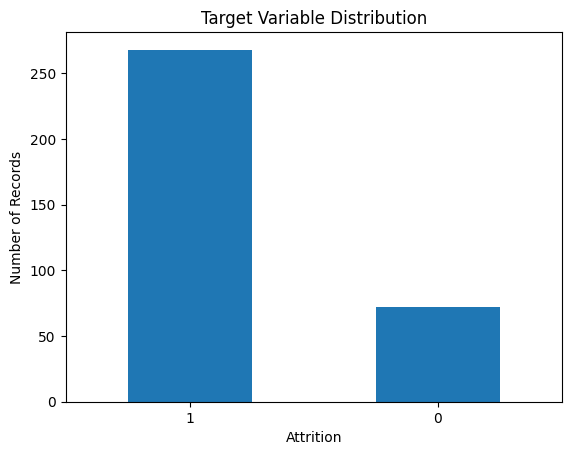

In [4]:
# Count the target variable values
target_distribution = df["attrition"].value_counts()

# Count the target variable values as percentages
target_distribution_percent = df["attrition"].value_counts(normalize=True) * 100

# Create a target distribution table
target_distribution_table = pd.DataFrame({
    "Count": target_distribution,
    "Percentage": target_distribution_percent.round(2)
})

# Display the target distribution table
display(target_distribution_table)

# Create a simple bar chart for the target variable distribution
target_distribution.plot(kind="bar")
plt.title("Target Variable Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

**Task 1 explanation**

My dataset has 340 records and 19 columns. The target is attrition. If attrition is 1, it means the employee left. If it is 0, it means the employee did not leave.
The dataset is clean because there are no missing values and no duplicate records.
The target is imbalanced because there are many more attrition cases than non-attrition cases. There are 268 cases of class 1 and only 72 cases of class 0. Because of that, I should not judge the model by accuracy alone.

*I also need to check precision, recall, F1-score, and the confusion matrix.*

## Task 2: Define Features and Target Variable

In [5]:
# Define the target column
target_column = "attrition"

# Define identifier columns that should not be used as model input
identifier_columns = ["employee_id"]

# Define group-related columns for fairness reflection only
fairness_column_names = ["gender", "age_group", "region"]

# Define the target variable
y = df[target_column]

# Keep fairness columns separately for later fairness analysis
fairness_columns = df[fairness_column_names]

# Define the input features by removing identifier, target, and fairness columns
X_raw = df.drop(columns=identifier_columns + [target_column] + fairness_column_names)

# Print the target column
print("Target column:", target_column)

# Print removed columns
print("Removed identifier columns:", identifier_columns)
print("Columns kept only for fairness reflection:", fairness_column_names)

# Print feature columns used by the model
print("Input feature columns used by the model:")
print(X_raw.columns.tolist())

# Display the first few rows of input features
display(X_raw.head())

Target column: attrition
Removed identifier columns: ['employee_id']
Columns kept only for fairness reflection: ['gender', 'age_group', 'region']
Input feature columns used by the model:
['age', 'department', 'job_level', 'employment_type', 'monthly_salary', 'years_at_company', 'years_in_current_role', 'overtime_hours', 'training_hours_last_year', 'performance_rating', 'job_satisfaction', 'work_life_balance', 'promotion_last_2_years', 'commute_distance_km']


,age,department,job_level,employment_type,monthly_salary,years_at_company,years_in_current_role,overtime_hours,training_hours_last_year,performance_rating,job_satisfaction,work_life_balance,promotion_last_2_years,commute_distance_km
0,41,Finance,Senior,Full-time,6865,0,0,8,37,2,5,5,Yes,46
1,39,IT,Intermediate,Full-time,6067,13,8,13,22,3,2,3,No,54
2,29,Sales,Entry,Full-time,4547,4,3,29,77,5,4,3,No,58
3,35,HR,Intermediate,Full-time,6555,15,5,2,4,3,4,2,No,11
4,54,HR,Intermediate,Full-time,6435,21,1,34,74,3,1,3,No,61


**Task 2 explanation**

The target variable is attrition, which means the model is trying to predict whether an employee leaves or stays.

For the input features, I used work-related information such as salary, years at company, overtime hours, job satisfaction, department, job level, promotion history, and commute distance.

I removed employee_id because it is only an ID number. I also removed gender, age_group, and region from the model input. I kept them only for fairness analysis, so I can compare model performance across groups later.


## Task 3: Data Preprocessing

In [6]:
# Create a copy of the raw input features
X = X_raw.copy()

# Identify numerical columns
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Identify categorical columns
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

# Print numerical and categorical columns
print("Numerical columns:")
print(numerical_columns)

print()
print("Categorical columns:")
print(categorical_columns)

Numerical columns:
['age', 'monthly_salary', 'years_at_company', 'years_in_current_role', 'overtime_hours', 'training_hours_last_year', 'performance_rating', 'job_satisfaction', 'work_life_balance', 'commute_distance_km']

Categorical columns:
['department', 'job_level', 'employment_type', 'promotion_last_2_years']


In [7]:
# Fill missing numerical values with the median value of each numerical column
for column in numerical_columns:
    X[column] = X[column].fillna(X[column].median())

# Fill missing categorical values with the most frequent value of each categorical column
for column in categorical_columns:
    X[column] = X[column].fillna(X[column].mode()[0])

# Convert categorical columns into numerical dummy variables
X = pd.get_dummies(X, drop_first=True)

# Display the final feature set after preprocessing
print("Final feature set shape:", X.shape)
display(X.head())

Final feature set shape: (340, 21)


,age,monthly_salary,years_at_company,years_in_current_role,overtime_hours,training_hours_last_year,performance_rating,job_satisfaction,work_life_balance,commute_distance_km,department_HR,department_IT,department_Marketing,department_Operations,department_Sales,job_level_Intermediate,job_level_Manager,job_level_Senior,employment_type_Full-time,employment_type_Part-time,promotion_last_2_years_Yes
0,41,6865,0,0,8,37,2,5,5,46,False,False,False,False,False,False,False,True,True,False,True
1,39,6067,13,8,13,22,3,2,3,54,False,True,False,False,False,True,False,False,True,False,False
2,29,4547,4,3,29,77,5,4,3,58,False,False,False,False,True,False,False,False,True,False,False
3,35,6555,15,5,2,4,3,4,2,11,True,False,False,False,False,True,False,False,True,False,False
4,54,6435,21,1,34,74,3,1,3,61,True,False,False,False,False,True,False,False,True,False,False


**Task 3 explanation**

Preprocessing helps prepare the data for machine learning. The model needs clean numerical data to work properly.

I filled missing numerical values with the median and missing categorical values with the most common value. I also used pd.get_dummies() to change text categories, such as department and job level, into numerical columns.

## Task 4: Train/Test Split

In [8]:
# Import train_test_split to divide the dataset
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test, fairness_train, fairness_test = train_test_split(
    X,
    y,
    fairness_columns,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Print the size of each dataset
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (272, 21)
X_test shape: (68, 21)
y_train shape: (272,)
y_test shape: (68,)


**Task 4 explanation**

I split the dataset into training data and testing data. The training set has 272 records, and the testing set has 68 records.The training data is used to teach the model. The testing data is used to check whether the model can make good predictions on new data.
I used stratified splitting so both sets have a similar target distribution.

## Task 5: Train a Classification Model

In [9]:
# Import DecisionTreeClassifier from scikit-learn
from sklearn.tree import DecisionTreeClassifier

# Create a Decision Tree classification model
# max_depth=4 keeps the model simple and easier to explain
# random_state=42 makes the result reproducible
model = DecisionTreeClassifier(max_depth=4, random_state=42)

# Train the model using the training data
model.fit(X_train, y_train)

# Predict attrition values for the test data
y_pred = model.predict(X_test)

# Create a comparison table of actual and predicted values
prediction_comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

# Add a column to show whether each prediction is correct
prediction_comparison["Correct"] = prediction_comparison["Actual"] == prediction_comparison["Predicted"]

# Display the first 15 predictions
display(prediction_comparison.head(15))

,Actual,Predicted,Correct
0,1,1,True
1,1,1,True
2,1,1,True
3,0,1,False
4,1,1,True
5,1,1,True
6,1,1,True
7,1,1,True
8,1,1,True
9,0,1,False


**Task 5 explanation**

The model is trying to predict whether an employee will leave or stay.It learns from patterns in the data, such as job satisfaction, overtime hours, work-life balance, salary, age, and commute distance.
The comparison table helps us check the first few predictions by comparing the actual result with the model’s predicted result.


## Task 6: Evaluate the Model

In [10]:
# Import classification metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Calculate precision for the positive class attrition = 1
precision = precision_score(y_test, y_pred, zero_division=0)

# Calculate recall for the positive class attrition = 1
recall = recall_score(y_test, y_pred, zero_division=0)

# Calculate F1-score for the positive class attrition = 1
f1 = f1_score(y_test, y_pred, zero_division=0)

# Create a metrics table
metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [accuracy, precision, recall, f1]
})

# Round the metric scores
metrics_table["Score"] = metrics_table["Score"].round(4)

# Display the metrics table
display(metrics_table)

,Metric,Score
0,Accuracy,0.7794
1,Precision,0.8095
2,Recall,0.9444
3,F1-score,0.8718


**Task 6 explanation**

Accuracy shows how many predictions were correct overall.Precision shows how often the model is correct when it predicts attrition.Recall shows how many real attrition cases the model successfully finds.F1-score gives a balance between precision and recall.

*For this problem, recall is the most important metric because the company wants to identify employees who may leave. If recall is low, many at-risk employees will be missed.*


## Task 7: Confusion Matrix

In [11]:
# Import confusion matrix tools
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Extract true negative, false positive, false negative, and true positive
tn, fp, fn, tp = cm.ravel()

# Create a confusion matrix table
cm_table = pd.DataFrame(
    cm,
    index=["Actual 0: No Attrition", "Actual 1: Attrition"],
    columns=["Predicted 0: No Attrition", "Predicted 1: Attrition"]
)

# Display the confusion matrix table
display(cm_table)

# Display each confusion matrix value
print("True Negative:", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive:", tp)

,Predicted 0: No Attrition,Predicted 1: Attrition
Actual 0: No Attrition,2,12
Actual 1: Attrition,3,51


True Negative: 2
False Positive: 12
False Negative: 3
True Positive: 51


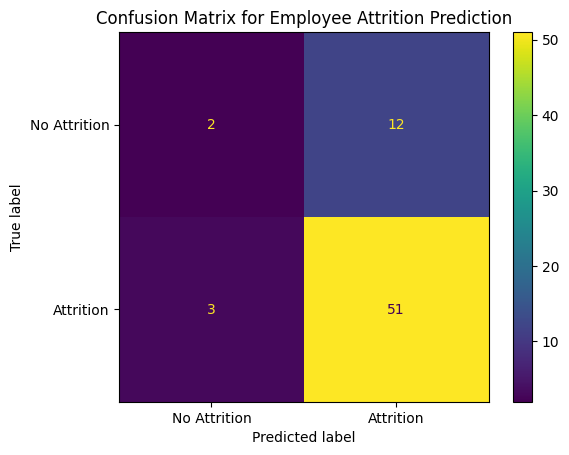

In [12]:
# Create a visual display of the confusion matrix
display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Attrition", "Attrition"]
)

# Plot the confusion matrix
display_cm.plot()
plt.title("Confusion Matrix for Employee Attrition Prediction")
plt.show()

**Task 7 explanation**
A true negative means the model correctly predicted that an employee would stay.
A true positive means the model correctly predicted that an employee was an attrition case.
A false positive means the model predicted attrition, but the employee stayed. This may cause unnecessary HR action or extra retention spending.
A false negative means the model predicted no attrition, but the employee actually left. This is more serious because the company may miss the chance to support an at-risk employee before they leave.


## Task 8: Error Analysis

In [13]:
# Create an error analysis table
error_analysis = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

# Define a function to label each prediction type
def label_error_type(row):
    if row["Actual"] == 0 and row["Predicted"] == 0:
        return "True Negative"
    elif row["Actual"] == 0 and row["Predicted"] == 1:
        return "False Positive"
    elif row["Actual"] == 1 and row["Predicted"] == 0:
        return "False Negative"
    else:
        return "True Positive"

# Apply the function to each row
error_analysis["Error Type"] = error_analysis.apply(label_error_type, axis=1)

# Add a correct or incorrect status column
error_analysis["Prediction Status"] = np.where(
    error_analysis["Actual"] == error_analysis["Predicted"],
    "Correct",
    "Incorrect"
)

# Display the first 20 rows of error analysis
display(error_analysis.head(20))

,Actual,Predicted,Error Type,Prediction Status
0,1,1,True Positive,Correct
1,1,1,True Positive,Correct
2,1,1,True Positive,Correct
3,0,1,False Positive,Incorrect
4,1,1,True Positive,Correct
5,1,1,True Positive,Correct
6,1,1,True Positive,Correct
7,1,1,True Positive,Correct
8,1,1,True Positive,Correct
9,0,1,False Positive,Incorrect


,Error Type,Count
0,True Positive,51
1,False Positive,12
2,False Negative,3
3,True Negative,2


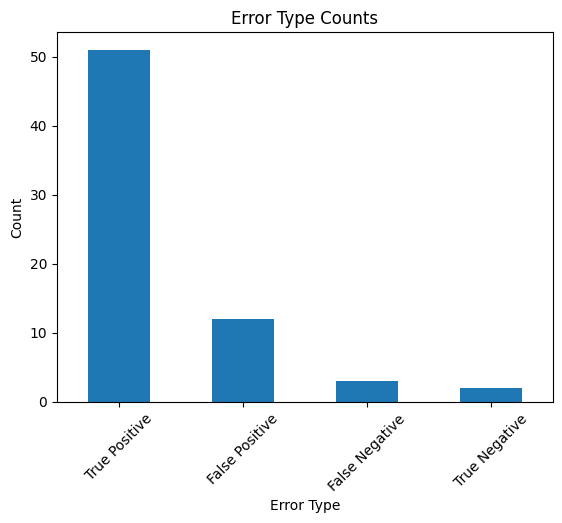

In [14]:
# Count each error type
error_type_counts = error_analysis["Error Type"].value_counts().reset_index()
error_type_counts.columns = ["Error Type", "Count"]

# Display error type counts
display(error_type_counts)

# Visualize error type counts
error_type_counts.plot(kind="bar", x="Error Type", y="Count", legend=False)
plt.title("Error Type Counts")
plt.xlabel("Error Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [15]:
# Create a table showing only wrong predictions
wrong_predictions = error_analysis[error_analysis["Prediction Status"] == "Incorrect"]

# Display wrong predictions
display(wrong_predictions)

,Actual,Predicted,Error Type,Prediction Status
3,0,1,False Positive,Incorrect
9,0,1,False Positive,Incorrect
13,0,1,False Positive,Incorrect
20,0,1,False Positive,Incorrect
21,0,1,False Positive,Incorrect
24,0,1,False Positive,Incorrect
25,1,0,False Negative,Incorrect
30,1,0,False Negative,Incorrect
34,0,1,False Positive,Incorrect
35,0,1,False Positive,Incorrect


**Task 8 explanation**

The most common wrong prediction is a false positive. This means the model predicts that an employee may leave, but the employee actually stays.The business impact is that the company may spend extra time or resources on employees who do not really need retention support.

False negatives are still more serious because they mean the model misses employees who actually leave.


## Task 9: Cross-Validation

In [16]:
# Import cross-validation tools
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Create a 5-fold cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Apply cross-validation using accuracy as the scoring metric
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

# Create a cross-validation results table
cv_results = pd.DataFrame({
    "Fold": range(1, len(cv_scores) + 1),
    "Accuracy": cv_scores
})

# Display cross-validation scores
print("Accuracy score for each fold:")
print(cv_scores)
print("Mean cross-validation accuracy:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

# Display table
display(cv_results)

Accuracy score for each fold:
[0.86764706 0.67647059 0.80882353 0.76470588 0.83823529]
Mean cross-validation accuracy: 0.7911764705882354
Standard deviation: 0.06668108263973314


,Fold,Accuracy
0,1,0.867647
1,2,0.676471
2,3,0.808824
3,4,0.764706
4,5,0.838235


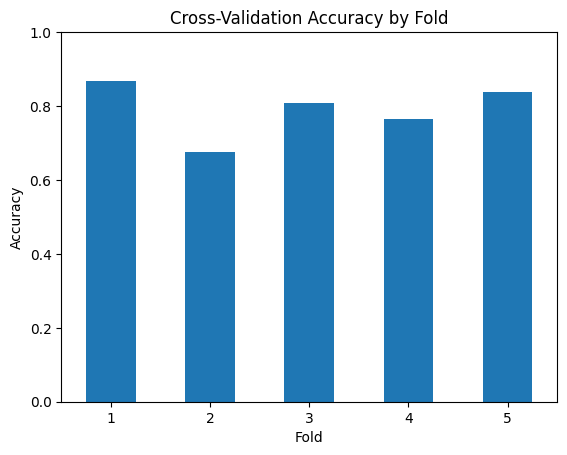

In [17]:
# Visualize cross-validation accuracy scores
cv_results.plot(kind="bar", x="Fold", y="Accuracy", legend=False)
plt.title("Cross-Validation Accuracy by Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

**Task 9 explanation**

Cross-validation tests the model on different splits of the dataset.The average accuracy is about 0.79, which means the model is correct around 79% of the time. The standard deviation is about 0.07, so the results change a little between folds.

This means the model is fairly stable, but the dataset may still be too small for real business use.


## Task 10: Overfitting and Underfitting Analysis

In [18]:
# Predict on the training data
y_train_pred = model.predict(X_train)

# Calculate training accuracy
training_accuracy = accuracy_score(y_train, y_train_pred)

# Calculate testing accuracy
testing_accuracy = accuracy_score(y_test, y_pred)

# Create a training and testing accuracy table
overfit_table = pd.DataFrame({
    "Dataset": ["Training Data", "Testing Data"],
    "Accuracy": [training_accuracy, testing_accuracy]
})

# Display the comparison table
display(overfit_table)

,Dataset,Accuracy
0,Training Data,0.882353
1,Testing Data,0.779412


In [19]:
# Create an empty list to store depth results
depth_results_list = []

# Test different max_depth values
for depth in range(1, 11):
    # Create a Decision Tree model with the current depth
    depth_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    
    # Train the model
    depth_model.fit(X_train, y_train)
    
    # Predict on training and testing data
    train_pred_depth = depth_model.predict(X_train)
    test_pred_depth = depth_model.predict(X_test)
    
    # Calculate training and testing accuracy
    train_acc_depth = accuracy_score(y_train, train_pred_depth)
    test_acc_depth = accuracy_score(y_test, test_pred_depth)
    
    # Store the result
    depth_results_list.append([depth, train_acc_depth, test_acc_depth])

# Create a DataFrame from the results
depth_results = pd.DataFrame(
    depth_results_list,
    columns=["Max Depth", "Training Accuracy", "Testing Accuracy"]
)

# Display the depth comparison table
display(depth_results)

,Max Depth,Training Accuracy,Testing Accuracy
0,1,0.786765,0.794118
1,2,0.841912,0.779412
2,3,0.867647,0.808824
3,4,0.882353,0.779412
4,5,0.908088,0.779412
5,6,0.926471,0.735294
6,7,0.948529,0.735294
7,8,0.963235,0.720588
8,9,0.988971,0.750000
9,10,1.000000,0.735294


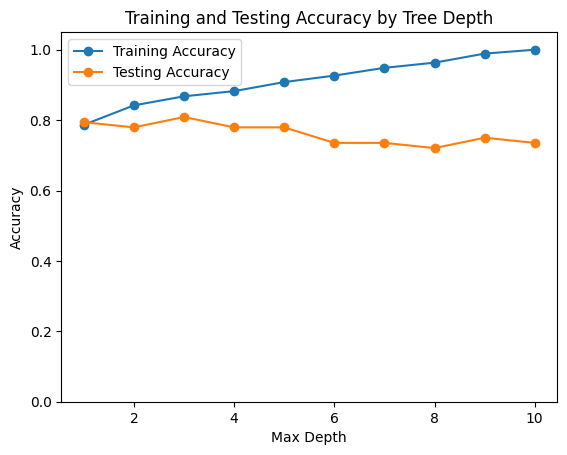

In [20]:
# Plot training and testing accuracy for different tree depths
plt.plot(depth_results["Max Depth"], depth_results["Training Accuracy"], marker="o", label="Training Accuracy")
plt.plot(depth_results["Max Depth"], depth_results["Testing Accuracy"], marker="o", label="Testing Accuracy")
plt.title("Training and Testing Accuracy by Tree Depth")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.show()

**Task 10 explanation**

The training accuracy is higher than the testing accuracy, so the model shows moderate overfitting.
When the tree depth becomes too deep, the training accuracy gets very high, but the testing accuracy does not improve much. This means the model is learning the training data too closely.

The model does not show strong underfitting because the training accuracy is still reasonably high.


## Task 11: Feature Importance

In [21]:
# Get feature importance values from the trained Decision Tree model
feature_importance_values = model.feature_importances_

# Create a feature importance table
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importance_values
})

# Sort features from most important to least important
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Display the feature importance table
display(feature_importance_df)

,Feature,Importance
7,job_satisfaction,0.339601
0,age,0.226169
4,overtime_hours,0.218633
8,work_life_balance,0.101951
1,monthly_salary,0.040256
9,commute_distance_km,0.040101
10,department_HR,0.033289
3,years_in_current_role,0.000000
2,years_at_company,0.000000
5,training_hours_last_year,0.000000


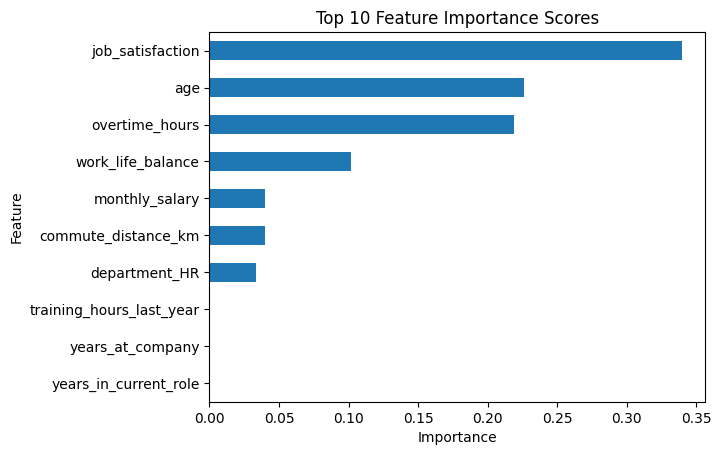

In [22]:
# Select the top 10 important features
top_features = feature_importance_df.head(10)

# Visualize the top 10 feature importance scores
top_features.sort_values(by="Importance").plot(kind="barh", x="Feature", y="Importance", legend=False)
plt.title("Top 10 Feature Importance Scores")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

**Task 11 explanation**

The most important features are job satisfaction, age, overtime hours, work-life balance, salary, commute distance, and department-related columns.This suggests that employee experience and workload are important signals for predicting attrition.

Feature importance does not prove cause and effect. For example, overtime hours may help the model make predictions, but this does not prove that overtime directly causes employees to leave.


## Task 12: SHAP Explanation

/opt/pyvenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


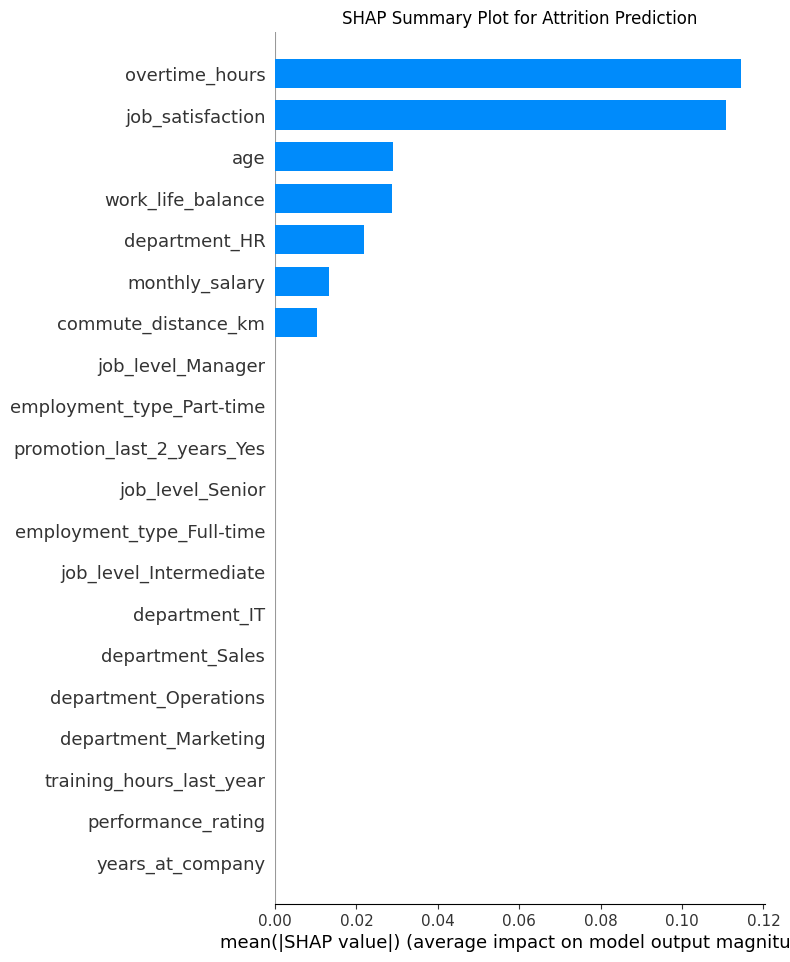

In [23]:
# Import SHAP for model explainability
import shap

# Create a SHAP TreeExplainer for the Decision Tree model
shap_explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test data
shap_values = shap_explainer.shap_values(X_test)

# SHAP may return values in different shapes depending on the package version
# This block selects SHAP values for the positive class attrition = 1
if isinstance(shap_values, list):
    shap_values_positive = shap_values[1]
else:
    shap_values_array = np.array(shap_values)
    if shap_values_array.ndim == 3:
        shap_values_positive = shap_values_array[:, :, 1]
    else:
        shap_values_positive = shap_values_array

# Create a SHAP summary bar plot
shap.summary_plot(shap_values_positive, X_test, plot_type="bar", show=False)
plt.title("SHAP Summary Plot for Attrition Prediction")
plt.show()

In [24]:
# Select one individual record from the test data
selected_index = 0
selected_record = X_test.iloc[[selected_index]]

# Get prediction probability for the selected record
selected_probability = model.predict_proba(selected_record)[0]

# Create a SHAP explanation table for the selected record
selected_shap_values = shap_values_positive[selected_index]

shap_individual_table = pd.DataFrame({
    "Feature": X_test.columns,
    "Feature Value": selected_record.iloc[0].values,
    "SHAP Value for Attrition Class": selected_shap_values
})

# Sort by absolute SHAP value to show the strongest local effects
shap_individual_table["Absolute SHAP Value"] = shap_individual_table["SHAP Value for Attrition Class"].abs()
shap_individual_table = shap_individual_table.sort_values(by="Absolute SHAP Value", ascending=False)

# Print prediction probability
print("Prediction probability for selected record:")
print("No Attrition probability:", selected_probability[0])
print("Attrition probability:", selected_probability[1])

# Display the top local SHAP effects
display(shap_individual_table.head(10))

Prediction probability for selected record:
No Attrition probability: 0.034482758620689655
Attrition probability: 0.9655172413793104


,Feature,Feature Value,SHAP Value for Attrition Class,Absolute SHAP Value
7,job_satisfaction,2,0.195544,0.195544
0,age,22,-0.103832,0.103832
8,work_life_balance,3,0.064427,0.064427
4,overtime_hours,9,0.020545,0.020545
10,department_HR,False,0.002952,0.002952
9,commute_distance_km,56,-0.002406,0.002406
1,monthly_salary,10256,0.001524,0.001524
3,years_in_current_role,1,0.000000,0.000000
2,years_at_company,2,0.000000,0.000000
5,training_hours_last_year,11,0.000000,0.000000


**Task 12 explanation**

SHAP helps explain how the model makes predictions.It shows whether each feature pushes the prediction toward attrition or away from attrition.

The summary plot explains the model overall, while the individual SHAP table explains one specific employee.SHAP is more detailed than basic feature importance because it shows both how important a feature is and how it affects the prediction.


## Task 13: LIME Explanation

In [25]:
# Import LIME for local explanation
# If LIME is not installed, uncomment the next two lines and run the cell again.
# import sys
# !{sys.executable} -m pip install lime

from lime.lime_tabular import LimeTabularExplainer

# Create a LIME tabular explainer using the training data
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    class_names=["No Attrition", "Attrition"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# Select one record for LIME explanation
lime_index = 0
lime_record = X_test.iloc[lime_index]

# Get prediction probability for the selected record
lime_probability = model.predict_proba(X_test.iloc[[lime_index]])[0]

# Define a prediction function that keeps the feature names
# This avoids warnings when LIME sends NumPy arrays to the model
def lime_predict_proba(data):
    data_df = pd.DataFrame(data, columns=X_train.columns)
    return model.predict_proba(data_df)

# Explain the selected prediction
lime_explanation = lime_explainer.explain_instance(
    data_row=lime_record.values,
    predict_fn=lime_predict_proba,
    num_features=8
)

# Convert LIME explanation to a table
lime_table = pd.DataFrame(
    lime_explanation.as_list(),
    columns=["Feature Condition", "Local Contribution"]
)

# Add a direction column
lime_table["Direction"] = np.where(
    lime_table["Local Contribution"] > 0,
    "Supports Attrition Prediction",
    "Works Against Attrition Prediction"
)

# Print prediction probability
print("Prediction probability for selected record:")
print("No Attrition probability:", lime_probability[0])
print("Attrition probability:", lime_probability[1])

# Display LIME explanation table
display(lime_table)

Prediction probability for selected record:
No Attrition probability: 0.034482758620689655
Attrition probability: 0.9655172413793104


,Feature Condition,Local Contribution,Direction
0,job_satisfaction <= 3.00,0.201062,Supports Attrition Prediction
1,8.00 < overtime_hours <= 16.00,-0.138370,Works Against Attrition Prediction
2,department_HR <= 0.00,0.080708,Supports Attrition Prediction
3,age <= 32.00,-0.073017,Works Against Attrition Prediction
4,2.00 < work_life_balance <= 3.00,0.034364,Supports Attrition Prediction
5,commute_distance_km > 51.00,-0.013722,Works Against Attrition Prediction
6,employment_type_Part-time <= 0.00,0.012747,Supports Attrition Prediction
7,department_Marketing <= 0.00,-0.011938,Works Against Attrition Prediction


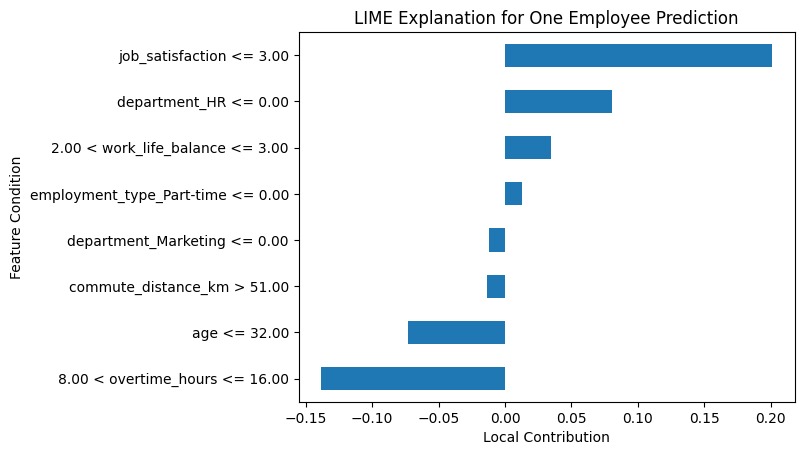

In [26]:
# Visualize the LIME explanation
lime_table.sort_values(by="Local Contribution").plot(
    kind="barh",
    x="Feature Condition",
    y="Local Contribution",
    legend=False
)
plt.title("LIME Explanation for One Employee Prediction")
plt.xlabel("Local Contribution")
plt.ylabel("Feature Condition")
plt.show()

**Task 13 explanation**

LIME explains one specific prediction.It shows which features support the predicted result and which features work against it.

This is helpful for business users because it gives simple reasons behind one prediction. For example, a manager can see whether the prediction is mainly affected by satisfaction, overtime, work-life balance, or other employee factors.


## Task 14: Fairness and Bias Reflection

In [27]:
# Create a fairness analysis DataFrame using the test set
fairness_analysis_df = fairness_test.copy()
fairness_analysis_df["Actual"] = y_test.values
fairness_analysis_df["Predicted"] = y_pred
fairness_analysis_df["Correct"] = fairness_analysis_df["Actual"] == fairness_analysis_df["Predicted"]

# Define a function to create fairness summary tables
def create_fairness_summary(data, group_column):
    summary = data.groupby(group_column).agg(
        Number_of_records=("Actual", "count"),
        Actual_positive_rate=("Actual", "mean"),
        Predicted_positive_rate=("Predicted", "mean"),
        Accuracy_by_group=("Correct", "mean")
    ).reset_index()
    
    summary["Actual_positive_rate"] = summary["Actual_positive_rate"].round(4)
    summary["Predicted_positive_rate"] = summary["Predicted_positive_rate"].round(4)
    summary["Accuracy_by_group"] = summary["Accuracy_by_group"].round(4)
    
    return summary

# Create fairness summaries for three group-related columns
fairness_gender = create_fairness_summary(fairness_analysis_df, "gender")
fairness_age_group = create_fairness_summary(fairness_analysis_df, "age_group")
fairness_region = create_fairness_summary(fairness_analysis_df, "region")

# Display fairness summary tables
print("Fairness summary by gender")
display(fairness_gender)

print("Fairness summary by age group")
display(fairness_age_group)

print("Fairness summary by region")
display(fairness_region)

Fairness summary by gender


,gender,Number_of_records,Actual_positive_rate,Predicted_positive_rate,Accuracy_by_group
0,Female,31,0.8710,0.9677,0.8387
1,Male,37,0.7297,0.8919,0.7297


Fairness summary by age group


,age_group,Number_of_records,Actual_positive_rate,Predicted_positive_rate,Accuracy_by_group
0,18-25,4,1.0000,1.0000,1.0000
1,26-35,22,0.7727,0.9091,0.7727
2,36-50,23,0.6522,0.8696,0.6087
3,51+,19,0.9474,1.0000,0.9474


Fairness summary by region


,region,Number_of_records,Actual_positive_rate,Predicted_positive_rate,Accuracy_by_group
0,East,23,0.9130,0.9565,0.9565
1,North,21,0.7143,0.9048,0.6190
2,South,13,0.7692,0.8462,0.7692
3,West,11,0.7273,1.0000,0.7273


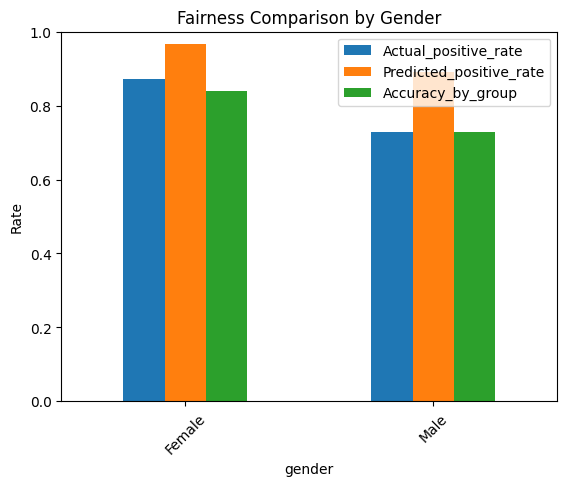

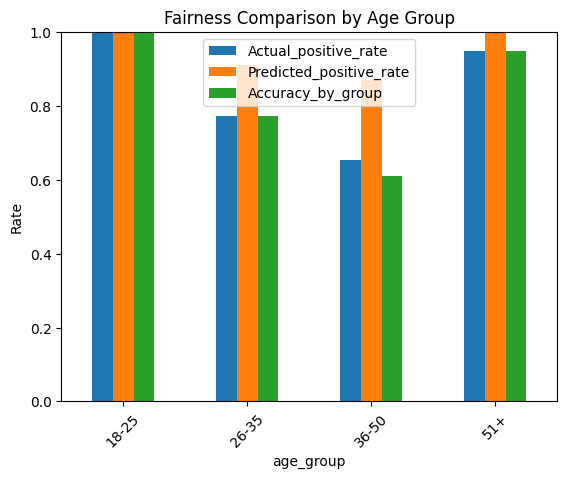

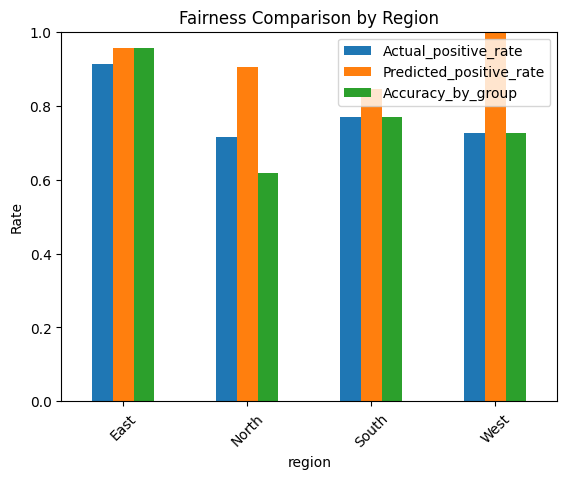

In [28]:
# Define a function to visualize fairness summaries
def plot_fairness_summary(summary, group_column, title):
    plot_data = summary.set_index(group_column)[[
        "Actual_positive_rate",
        "Predicted_positive_rate",
        "Accuracy_by_group"
    ]]
    
    plot_data.plot(kind="bar")
    plt.title(title)
    plt.xlabel(group_column)
    plt.ylabel("Rate")
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.legend(loc="best")
    plt.show()

# Visualize fairness summary by gender
plot_fairness_summary(fairness_gender, "gender", "Fairness Comparison by Gender")

# Visualize fairness summary by age group
plot_fairness_summary(fairness_age_group, "age_group", "Fairness Comparison by Age Group")

# Visualize fairness summary by region
plot_fairness_summary(fairness_region, "region", "Fairness Comparison by Region")

**Task 14 explanation**

The fairness analysis checks whether the model performs the same across different groups.I compared actual positive rate, predicted positive rate, and accuracy by group. The results show that the model does not behave exactly the same for every group.Even though gender, age_group, and region were removed from the model input, other features may still act as indirect signals. Because of this, the model needs careful review before real business use.


## Task 15: Final Business Interpretation

In [29]:
# Print final summary values for business interpretation
print("Final Model Summary")
print("-" * 50)
print("Model: Decision Tree Classifier")
print("Target: attrition")
print("Testing Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))
print("Training Accuracy:", round(training_accuracy, 4))
print("Testing Accuracy:", round(testing_accuracy, 4))
print("Most important feature:", feature_importance_df.iloc[0]["Feature"])
print("Main wrong prediction type: False Positive")

Final Model Summary
--------------------------------------------------
Model: Decision Tree Classifier
Target: attrition
Testing Accuracy: 0.7794
Precision: 0.8095
Recall: 0.9444
F1-score: 0.8718
Training Accuracy: 0.8824
Testing Accuracy: 0.7794
Most important feature: job_satisfaction
Main wrong prediction type: False Positive


**Final business interpretation**

This model predicts employee attrition. It can help HR identify employees who may be at risk of leaving.
The model uses a Decision Tree with a maximum depth of 4, so it is easier to explain than a very complex model.
The testing accuracy is about 0.78, and the recall is about 0.94. Recall is important here because the company wants to catch most real attrition cases.
The main error type is false positive. This means the model sometimes predicts that an employee may leave when the employee actually stays. This could lead to extra retention effort or unnecessary management attention. False negatives are less common, but they are more serious because the company may miss an employee who actually leaves.
The model also shows moderate overfitting because training accuracy is higher than testing accuracy. The most important features are job satisfaction, age, overtime hours, work-life balance, salary, commute distance, and department-related columns.

*SHAP and LIME make the model easier to understand because they explain individual predictions. The fairness analysis shows that performance is not exactly the same across gender, age group, and region.*